In [55]:
from ase.build import fcc111, fcc100
from ase.calculators.espresso import Espresso, EspressoProfile
import numpy as np
import os; 
from ase.visualize import view
from ase.build import bulk

import re
from ase.io.trajectory import Trajectory
from ase.eos import EquationOfState
from ase.io import read
from ase.units import kJ

os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_PLACES"] = "cores"
os.environ["OMP_PROC_BIND"] = "close"
np.set_printoptions(precision=8, suppress=True)

In [56]:
# Define pseudopotentials and input data for Quantum ESPRESSO
profile = EspressoProfile(
    command='mpirun -np 4 pw.x', pseudo_dir='/home/jovyan/espresso/pseudo')

pseudopotentials = {'Cu': 'Cu.pbe-dn-kjpaw_psl.1.0.0.UPF'} # a dict!

In [57]:
input_data = {
    'control': {
        'calculation': 'scf',
        'etot_conv_thr' :   0.00001,
        'verbosity' : 'low',
        'outdir': 'tmp',
    },
    'system': {
        'ecutwfc': 25,    # Plane-wave cutoff energy in Ry
        'ecutrho': 300,   # Charge density cutoff in Ry
        'occupations': 'smearing',
        'smearing': 'marzari-vanderbilt',
        'degauss': 0.02,  # Width of smearing in Ry
    },
    'electrons': {
        'conv_thr': 1e-8,  # Convergence threshold
        'mixing_beta': 0.7
    },
}
kpts = (12, 12, 12)  # k-point grid for the slab

In [58]:
calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                tstress=False, tprnfor=False, kpts=kpts, input_data=input_data)

In [59]:
# Create a bulk FCC crystal for Cu
a_lat = 3.615 # Angstrom, initial Guess
bulk_system = bulk('Cu', 'fcc', a=a_lat)  # cubic=True
view(bulk_system, viewer="ngl")

In [60]:
# work arround due to bug in ASE Espresso front end... but you could extract by hand. 
# next returns the first match and stops! 
# 
#total_energy = next(float(line.split('=')[1].strip().split()[0]) for line in open("espresso.pwo") if line.startswith("!")); 
#print(f"Total energy: {total_energy} Ry")


#os.rename("espresso.pwo", "espresso.pwo.cu_slab"); 


In [61]:
bulk_system.calc = calc

# Calculate bulk energy per atom
bulk_energy = bulk_system.get_potential_energy() / len(bulk_system)

In [62]:
print(f"Bulk energy per atom: {bulk_energy:.6f} eV")

Bulk energy per atom: -2897.671375 eV


In [63]:
n_atoms = len(bulk_system)
print(n_atoms)

1


In [64]:
lat = bulk('Cu', 'fcc', a=3.62)
lat.calc = calc 
eps = 0.1

cell = lat.get_cell() 
print(f"Cu unit cell: {cell}")
traj = Trajectory('cu-eos.traj', 'w')

Cu unit cell: Cell([[0.0, 1.81, 1.81], [1.81, 0.0, 1.81], [1.81, 1.81, 0.0]])


In [65]:
for s in np.linspace((1-eps), (1+eps), 7):
    lat.set_cell(cell * s, scale_atoms=True)
    lat.get_potential_energy()
    traj.write(lat)

In [66]:
configs = read('cu-eos.traj@0:7')  # read all configurations
# Extract volumes and energies:
volumes = [c.get_volume() for c in configs]
energies = [c.get_potential_energy() for c in configs]

In [67]:
print(volumes, energies)

[8.645562378000001, 9.642198106074074, 10.71262616659259, 11.859481999999998, 13.085401046740747, 14.393018747259264, 15.784970542000005] [-2896.8230703269714, -2897.3309268604376, -2897.582682774368, -2897.6923646517134, -2897.6866148863023, -2897.5647605406125, -2897.3915897427164]


In [68]:
import pandas as pd
data = {
    'Volume': volumes,
    'Energy': energies
}
df = pd.DataFrame(data)
print(f"{df} \n !actually we should have used pandas df for the data from start!")

      Volume       Energy
0   8.645562 -2896.823070
1   9.642198 -2897.330927
2  10.712626 -2897.582683
3  11.859482 -2897.692365
4  13.085401 -2897.686615
5  14.393019 -2897.564761
6  15.784971 -2897.391590 
 !actually we should have used pandas df for the data from start!


In [69]:
eos = EquationOfState(volumes, energies)
v0, e0, B = eos.fit()

In [70]:
print(v0, e0, B / kJ * 1.0e24, 'GPa')

12.232535219988037 -2897.7020719463294 149.34111014755993 GPa


In [71]:
#a=np.pow(v0*4,1/3)
#print(a)
a = np.cbrt(4 * v0)
print(f"the equilibrium lattice parameter is {a}")

the equilibrium lattice parameter is 3.657565863359159


<Axes: title={'center': 'sj: E: -2897.702 eV, V: 12.233 Å$^3$, B: 149.341 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

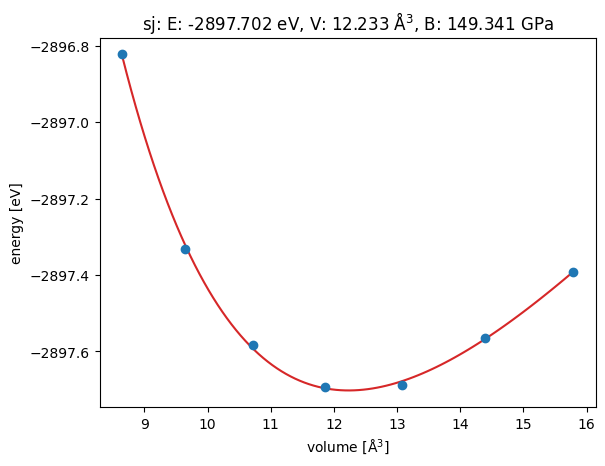

In [72]:
eos.plot('cu-eos.png')